# Fly-dysseus: the proof layer

The video runs in the Embodied Fly Lab's browser simulation. This notebook runs the **same experiments in the published whole-brain model** (Shiu et al., *Nature* 2024), so every number in the README can be checked.

It does three things:

1. **Reproduces the paper's headline result:** activating sugar-sensing neurons drives MN9, the motor neuron behind the fly's feeding mouthparts.
2. **Runs the three acts on the exact neurons the video uses:** normal, Wax (sugar neurons' outgoing synapses cut), Mast (MN9's outgoing synapses cut).
3. **Finds the Siren circuit:** the neurons that respond to the paper's sugar input, which the video's Siren circuit view highlights.

**Setup**

- Clone [Shiu et al.'s repo](https://github.com/philshiu/Drosophila_brain_model) next to this repo, so the folders sit side by side.
- Install: `pip install brian2 pandas pyarrow joblib matplotlib`
- Run this notebook from the `proof/` folder.

Each whole-brain run takes roughly 1.5 to 6 minutes on a laptop CPU. Results are cached in `proof/results/`, so reruns are instant.

In [8]:
import json, os, re, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path.cwd().parent                               # this repo (fly-dysseus)
SHIU = REPO.parent / "Drosophila_brain_model"           # Shiu et al.'s repo, cloned alongside
assert (REPO / "data" / "manifest.json").exists(), "Run this notebook from the proof/ folder"
assert (SHIU / "model.py").exists(), f"Shiu et al.'s repo not found at {SHIU}"

sys.path.insert(0, str(SHIU))
from model import run_exp, default_params as params
import utils as utl
from brian2 import Hz

RESULTS = Path.cwd() / "results"
cfg630 = {"path_res": str(RESULTS / "v630"), "n_proc": -1,
          "path_comp": str(SHIU / "2023_03_23_completeness_630_final.csv"),
          "path_con": str(SHIU / "2023_03_23_connectivity_630_final.parquet")}
cfg783 = {"path_res": str(RESULTS / "v783"), "n_proc": -1,
          "path_comp": str(SHIU / "Completeness_783.csv"),
          "path_con": str(SHIU / "Connectivity_783.parquet")}
for cfg in (cfg630, cfg783):
    os.makedirs(cfg["path_res"], exist_ok=True)

print("Default stimulation rate:", params["r_poi"], "| trials:", params["n_run"], "| trial length:", params["t_run"])

Default stimulation rate: 150. Hz | trials: 30 | trial length: 1. s


## The neurons

- **v630 sugar neurons:** the 21 sugar-sensing neurons from Shiu et al.'s own `example.ipynb`, read straight from that file so nothing is retyped.
- **v783 neurons:** the exact populations the Embodied Fly Lab uses, read from its `data/` folder, so both layers talk about identical neurons.

In [9]:
# v630: the paper's sugar neurons, taken from Shiu et al.'s example notebook
example = json.load(open(SHIU / "example.ipynb"))
source = "".join("".join(c["source"]) for c in example["cells"] if c["cell_type"] == "code")
block = re.search(r"neu_sugar\s*=\s*\[(.*?)\]", source, re.S)
neu_sugar_630 = [int(x) for x in re.findall(r"\d{15,}", block.group(1))]
MN9_630 = 720575940660219265                            # the MN9 used in Shiu et al.'s example
print("v630 sugar neurons:", len(neu_sugar_630))
assert len(neu_sugar_630) == 21

# v783: the fly lab's populations, by FlyWire ID
manifest = json.load(open(REPO / "data" / "manifest.json"))
root_ids = np.fromfile(REPO / "data" / "root-ids.u64", dtype="<u8")
assert len(root_ids) == manifest["neuron_count"]
ids = lambda pop: [int(root_ids[i]) for i in manifest["populations"][pop]]

sugar_lab = ids("sugar_left") + ids("sugar_right")      # what the video stimulates on contact
sugar_ref = ids("sugar_shiu_reference")                 # the paper's sugar neurons, as they exist in v783
mn9 = ids("feed_mn9")                                   # left and right MN9
print("lab sugar neurons:", len(sugar_lab), "| reference sugar neurons:", len(sugar_ref), "| MN9:", mn9)

roster = set(pd.read_csv(SHIU / "Completeness_783.csv", index_col=0).index)
missing = [n for n in sugar_lab + sugar_ref + mn9 if n not in roster]
assert not missing, f"not in the v783 roster: {missing}"

v630 sugar neurons: 21
lab sugar neurons: 122 | reference sugar neurons: 20 | MN9: [720575940618238523, 720575940660219265]


## 1. Reproduce the paper

Stimulate the 21 sugar neurons at 100 Hz (30 trials of 1 s) and read MN9.

In [10]:
run_exp(exp_name="sugarR", neu_exc=neu_sugar_630, params={**params, "r_poi": 100 * Hz}, **cfg630)

rates630, _ = utl.get_rate(utl.load_exps([f"{cfg630['path_res']}/sugarR.parquet"]),
                           t_run=params["t_run"], n_run=params["n_run"])
rates630 = rates630.fillna(0)
print(f"MN9: {rates630.loc[MN9_630, 'sugarR']:.1f} Hz   (published example: 67.0 Hz)")

responding630 = rates630[rates630["sugarR"] > 0].drop(index=neu_sugar_630 + [MN9_630], errors="ignore")
print("neurons responding to sugar (v630):", len(responding630))

>>> Skipping experiment sugarR because /Users/saadaamir/fly-odyssey/embodied-fly-lab/proof/results/v630/sugarR.parquet exists and force_overwrite = False
MN9: 66.9 Hz   (published example: 67.0 Hz)
neurons responding to sugar (v630): 381


## 2. The three acts, on the video's exact input

FlyWire v783, the fly lab's 122 sugar neurons at 200 Hz:

- **Normal:** sugar neurons stimulated.
- **Wax:** sugar neurons stimulated *and* silenced. In this model, silencing zeroes a neuron's outgoing synapses only: it still fires, nobody hears it. (The model's README says "to and from", but the code cuts outgoing only; see issue #10 on Shiu et al.'s repo.)
- **Mast:** sugar neurons stimulated, MN9 silenced. MN9 still receives input and fires; its output is cut.

In [ ]:
params_lab = {**params, "r_poi": 200 * Hz}
run_exp(exp_name="lab_sugar", neu_exc=sugar_lab, params=params_lab, **cfg783)
run_exp(exp_name="lab_wax", neu_exc=sugar_lab, neu_slnc=sugar_lab, params=params_lab, **cfg783)
run_exp(exp_name="lab_mast", neu_exc=sugar_lab, neu_slnc=mn9, params=params_lab, **cfg783)

acts = ["lab_sugar", "lab_wax", "lab_mast"]
rates783, _ = utl.get_rate(utl.load_exps([f"{cfg783['path_res']}/{a}.parquet" for a in acts]),
                           t_run=params["t_run"], n_run=params["n_run"])
rates783 = rates783.fillna(0)[acts]

print("MN9 firing rate (Hz):")
print(rates783.reindex(mn9).fillna(0).round(1).to_string())

responding = rates783[rates783["lab_sugar"] > 0].drop(index=sugar_lab + mn9, errors="ignore")
print("\nneurons responding to sugar:", len(responding))
for act in ["lab_wax", "lab_mast"]:
    change = (responding[act] - responding["lab_sugar"]).abs().mean()
    print(f"{act}: average change {change:.1f} Hz")

>>> Skipping experiment lab_sugar because /Users/saadaamir/fly-odyssey/embodied-fly-lab/proof/results/v783/lab_sugar.parquet exists and force_overwrite = False
>>> Skipping experiment lab_wax because /Users/saadaamir/fly-odyssey/embodied-fly-lab/proof/results/v783/lab_wax.parquet exists and force_overwrite = False
>>> Skipping experiment lab_mast because /Users/saadaamir/fly-odyssey/embodied-fly-lab/proof/results/v783/lab_mast.parquet exists and force_overwrite = False


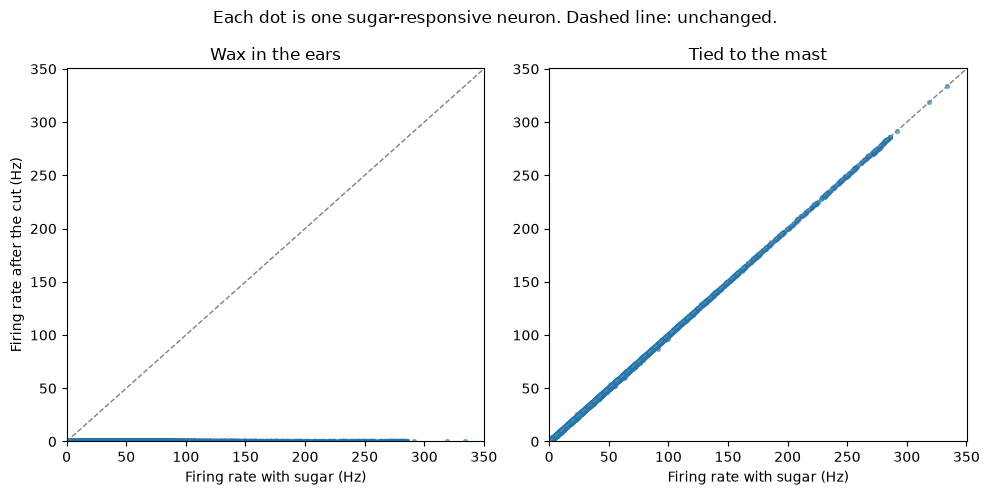

In [ ]:
lim = responding["lab_sugar"].max() * 1.05
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, act, name in [(axes[0], "lab_wax", "Wax in the ears"), (axes[1], "lab_mast", "Tied to the mast")]:
    ax.scatter(responding["lab_sugar"], responding[act], s=8, alpha=0.5)
    ax.plot([0, lim], [0, lim], "--", color="grey", linewidth=1)
    ax.set(title=name, xlabel="Firing rate with sugar (Hz)", xlim=(0, lim), ylim=(0, lim))
axes[0].set_ylabel("Firing rate after the cut (Hz)")
fig.suptitle("Each dot is one sugar-responsive neuron. Dashed line: unchanged.")
plt.tight_layout()
plt.savefig("odysseus_scatter.png", dpi=200)
plt.show()

## 3. The Siren circuit

The fly lab's sugar input is much stronger than the paper's, so it recruits a very broad response. For the video's circuit view, use the **core** instead: the neurons that respond to the paper's own input (the 20 reference sugar neurons at 100 Hz on v783).

This cell also compares against the committed `data/siren-circuit.json`. Spiking is random, so a fresh run can differ by a few neurons; set `WRITE_SIREN = True` only if you want to overwrite the file the video uses.

In [ ]:
params_paper = {**params, "r_poi": 100 * Hz}
run_exp(exp_name="paper_sugar", neu_exc=sugar_ref, params=params_paper, **cfg783)

paper, _ = utl.get_rate(utl.load_exps([f"{cfg783['path_res']}/paper_sugar.parquet"]),
                        t_run=params["t_run"], n_run=params["n_run"])
paper = paper.fillna(0)
print("MN9 with the paper's input, brain alone (Hz):", paper.reindex(mn9).fillna(0)["paper_sugar"].round(1).tolist())

core = paper[paper["paper_sugar"] > 0].drop(index=sugar_ref + mn9, errors="ignore")
print("core circuit neurons:", len(core), "| also respond to the lab's input:", int(core.index.isin(responding.index).sum()))

index_of = {int(r): i for i, r in enumerate(root_ids)}
siren = {
    "inputs": [index_of[n] for n in sugar_lab],
    "circuit": {index_of[int(n)]: round(float(r), 2) for n, r in responding["lab_sugar"].items()},
    "mn9": [index_of[n] for n in mn9],
    "core": {index_of[int(n)]: round(float(r), 2) for n, r in core["paper_sugar"].items()},
}

committed = REPO / "data" / "siren-circuit.json"
if committed.exists():
    old_core = set(json.load(open(committed))["core"])
    new_core = {str(k) for k in siren["core"]}
    print(f"matches the committed circuit: {len(old_core & new_core)} of {len(old_core)} core neurons")

WRITE_SIREN = False
if WRITE_SIREN:
    json.dump(siren, open(committed, "w"))
    print("wrote", committed)

>>> Skipping experiment paper_sugar because /Users/saadaamir/fly-odyssey/embodied-fly-lab/proof/results/v783/paper_sugar.parquet exists and force_overwrite = False
MN9 with the paper's input, brain alone (Hz): [48.0, 62.5]
core circuit neurons: 378 | also respond to the lab's input: 354
matches the committed circuit: 378 of 378 core neurons


## Credits

Model and code: Shiu et al., *A Drosophila computational brain model reveals sensorimotor processing*, Nature 2024. Connectome: FlyWire (FAFB v630 and v783). Connectivity files via Eon Systems. Neuron populations for v783 from the Embodied Fly Lab.